# Titanic Survival Prediction Using Three Methods

This notebook predicts whether a Titanic passenger survived using three machine learning models:
Logistic Regression, Random Forest, XGBoost



Main Workflow


## 1. Import Libraries

I used:

-  pandas  and  numpy  for data processing
-  matplotlib  and  seaborn  for figures
-  scikit-learn  for Logistic Regression, Random Forest, and evaluation metrics
-  xgboost for the XGBoost model

In [10]:
#pip install xgboost

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier



## 2. Loading the Dataset

The Titanic dataset contains passenger info:class, sex, age, fare, and survival status.

The target variable is:
If the passenger survived it will have a value of 1. If they did not survive they will have a value of 0


In [12]:
df = pd.read_csv("titanic_train.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploring data

before modeling, I checked column types and missing values.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [14]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

## 4. Exploring data using graphs

light areas indicate missing values.

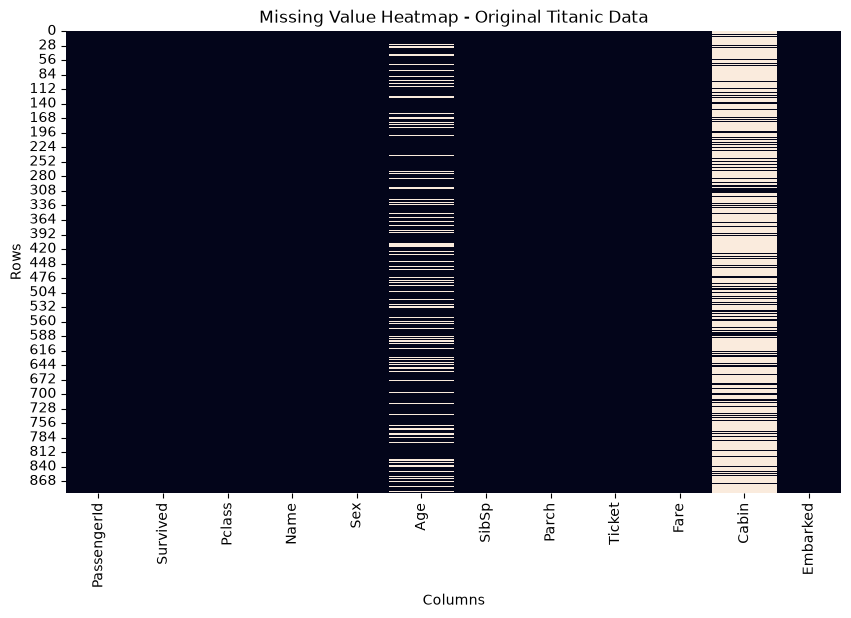

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap - Original Titanic Data")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## 5. Analyzing Data

I had to understand the data in order to train my models on it. 

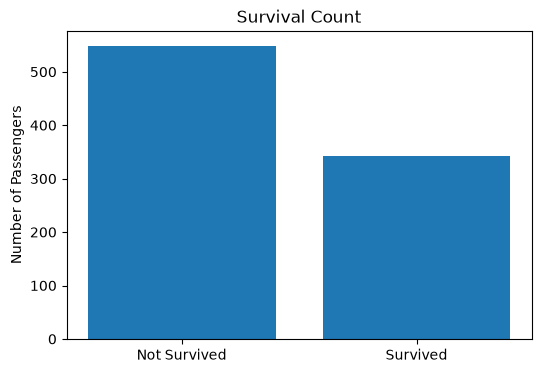

In [16]:
#survival count
survival_counts = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not Survived", "Survived"], survival_counts.values)
plt.title("Survival Count")
plt.ylabel("Number of Passengers")
plt.show()

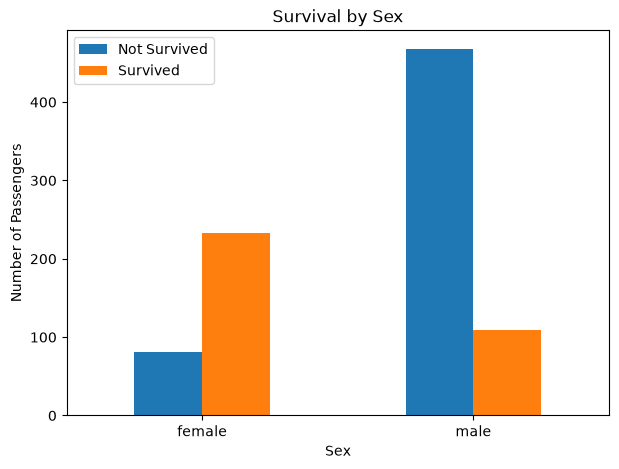

In [17]:
#survival by sex
sex_survival = pd.crosstab(df["Sex"], df["Survived"])
sex_survival.columns = ["Not Survived", "Survived"]

sex_survival.plot(kind="bar", figsize=(7, 5))
plt.title("Survival by Sex")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()

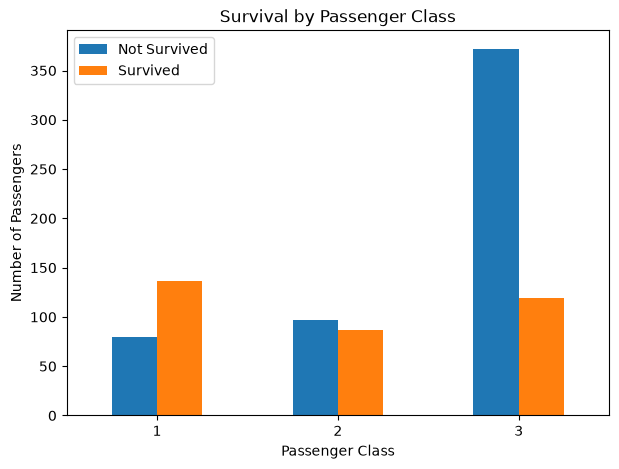

In [18]:
# survival by passenger class
class_survival = pd.crosstab(df["Pclass"], df["Survived"])
class_survival.columns = ["Not Survived", "Survived"]

class_survival.plot(kind="bar", figsize=(7, 5))
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()

## 6. Preparing the data

I used the same features for each model. 

Selected Features

- Pclass: passenger class
- Sex: passenger gender
- Age: passenger age
- SibSp: number of siblings/spouses aboard
- Parch: number of parents/children aboard
- Fare: ticket fare
- Embarked: port of embarkation

### Cleaning Steps

- Fill missing Age with median age
- Fill missing Fare with median fare
- Fill missing Embarked with the mode

In [19]:
# copy the original data before cleaning
data = df.copy()

# fill missing values
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Fare"] = data["Fare"].fillna(data["Fare"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# selecting input features and target
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = data[features]
y = data["Survived"]

# convert categorical variables into dummy values
X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)

print("Prepared feature shape:", X.shape)
X.head()

Prepared feature shape: (891, 8)


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## 7. Correlation Heatmap

This heatmap shows the correlation between processed numeric features and whether the passenger survived. Big values mean it is highly correlated with survival

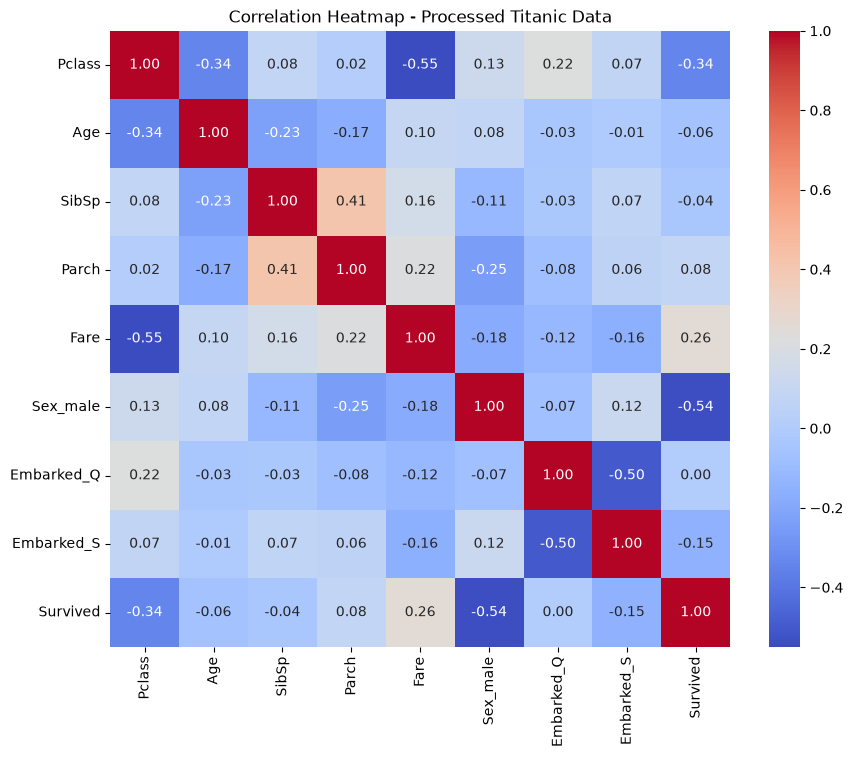

In [20]:
corr_data = pd.concat([X, y], axis=1)
corr = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Processed Titanic Data")
plt.show()

## 8. Train/Test Split Data

I split the data into training and testing sets.

The same split is used for all three models, so the comparison will be fair.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


# Model 1: Logistic Regression

## Method Explanation

It estimates the probability that a passenger survived.  


In [22]:
# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_model.fit(X_train, y_train)

# Predict on test data
log_pred = log_model.predict(X_test)

# Evaluate the model
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Logistic Regression Results")
print("Accuracy:", round(log_accuracy, 3))
print("Precision:", round(log_precision, 3))
print("Recall:", round(log_recall, 3))
print("F1-score:", round(log_f1, 3))

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Logistic Regression Results
Accuracy: 0.804
Precision: 0.793
Recall: 0.667
F1-score: 0.724

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



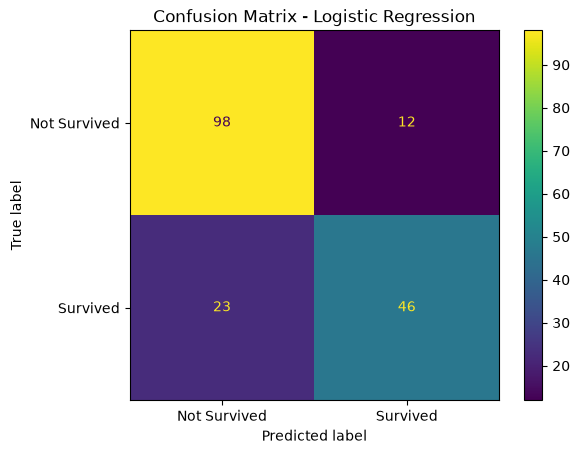

In [ ]:
#confusion matrix for Logistic regression
cm_log = confusion_matrix(y_test, log_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Not Survived", "Survived"]
)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [24]:
# logistic regression coefficients
log_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

log_coef

,Feature,Coefficient
6,Embarked_Q,0.277863
4,Fare,0.002254
1,Age,-0.038536
3,Parch,-0.070927
2,SibSp,-0.245127
7,Embarked_S,-0.381281
0,Pclass,-1.090595
5,Sex_male,-2.558956


# Model 2: Random Forest

## Method Explanation

Random Forest is a model made of many decision trees.


In [25]:
# creating Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# training the model
rf_model.fit(X_train,y_train)

# predicting on test data
rf_pred = rf_model.predict(X_test)

# evaluating the model
rf_accuracy = accuracy_score(y_test,rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test,rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("Accuracy:", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall:", round(rf_recall, 3))
print("F1-score:", round(rf_f1, 3))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy: 0.793
Precision: 0.82
Recall: 0.594
F1-score: 0.689

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       110
           1       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



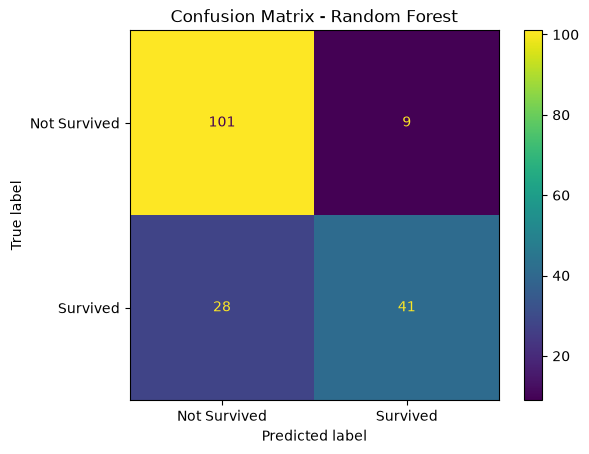

In [ ]:
#confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not Survived", "Survived"]
)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
#random Forest feature importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance

,Feature,Importance
5,Sex_male,0.437827
4,Fare,0.179807
0,Pclass,0.141395
1,Age,0.117967
2,SibSp,0.046824
3,Parch,0.036575
7,Embarked_S,0.027940
6,Embarked_Q,0.011664


# Model 3: XGBoost

## Method Explanation

XGBoost builds decision trees one by one.  


In [28]:
# creating XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

#training the model
xgb_model.fit(X_train, y_train)

#predicting on test data
xgb_pred = xgb_model.predict(X_test)

#evaluating the model
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("XGBoost Results")
print("Accuracy:", round(xgb_accuracy, 3))
print("Precision:", round(xgb_precision, 3))
print("Recall:", round(xgb_recall, 3))
print("F1-score:", round(xgb_f1, 3))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Results
Accuracy: 0.788
Precision: 0.782
Recall: 0.623
F1-score: 0.694

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       110
           1       0.78      0.62      0.69        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179



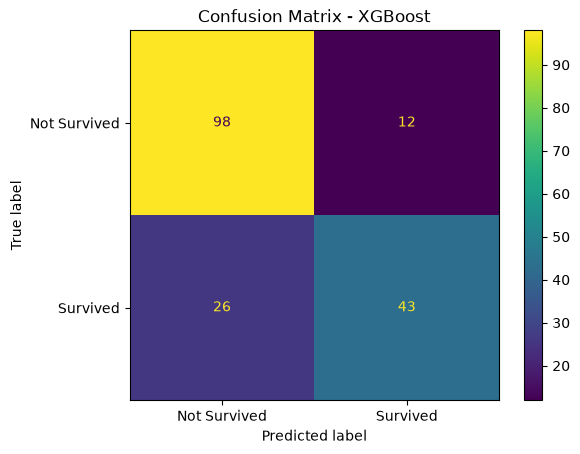

In [29]:
#confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Not Survived", "Survived"]
)
disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [30]:
#XGBoost feature importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_importance

,Feature,Importance
5,Sex_male,0.600452
0,Pclass,0.184996
7,Embarked_S,0.057240
1,Age,0.050596
2,SibSp,0.049427
4,Fare,0.044114
3,Parch,0.011559
6,Embarked_Q,0.001616


# Final Model Comparison

Now we compare the three models using accuracy, precision, recall, and f1-scores.


In [31]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [log_accuracy, rf_accuracy, xgb_accuracy],
    "Precision": [log_precision, rf_precision, xgb_precision],
    "Recall": [log_recall, rf_recall, xgb_recall],
    "F1-score": [log_f1, rf_f1, xgb_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
1,Random Forest,0.793296,0.820000,0.594203,0.689076
2,XGBoost,0.787709,0.781818,0.623188,0.693548


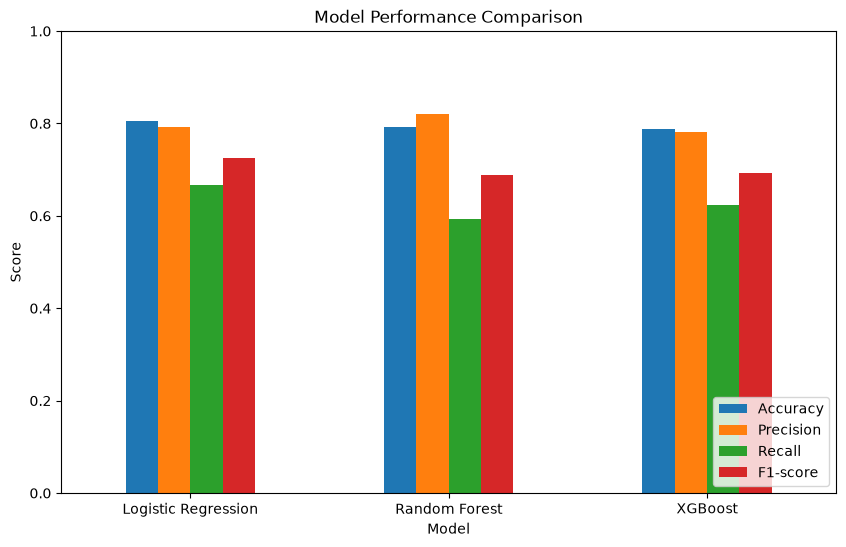

In [32]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

Summary

In this notebook, i built three models independently:

Logistic Regression, Random Forest, XGBoost

Each model was trained, predicted, and evaluated separately.  
Then I compared their performance using Accuracy, Precision, Recall, and F1-score.


The best model can be selected from the comparison table based on the metric most important for the task.

For this Titanic survival prediction task, the features most related to survival are usually passenger sex, passenger class, fare, and age.